# Validation 06 — Filter Design & Frequency Responses (Cell 16)
Verifies all 225 filters design without error, passband gain, and relative rolloff.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  All filters designed without error  → 225/225 OK
  [PASS]  SOS arrays have 6 columns
  [PASS]  Butterworth: passband gain at 505 Hz > -6 dB  → -0.0 dB
  [PASS]  Chebyshev I: passband gain at 505 Hz > -6 dB  → -0.2 dB
  [PASS]  Chebyshev II: passband gain at 505 Hz > -6 dB  → -0.2 dB
  [PASS]  Elliptical: passband gain at 505 Hz > -6 dB  → -0.4 dB
  [PASS]  Bessel: passband gain at 505 Hz > -6 dB  → -1.8 dB
  [PASS]  Elliptical sharper stopband than Bessel  → sharper rolloff confirmed


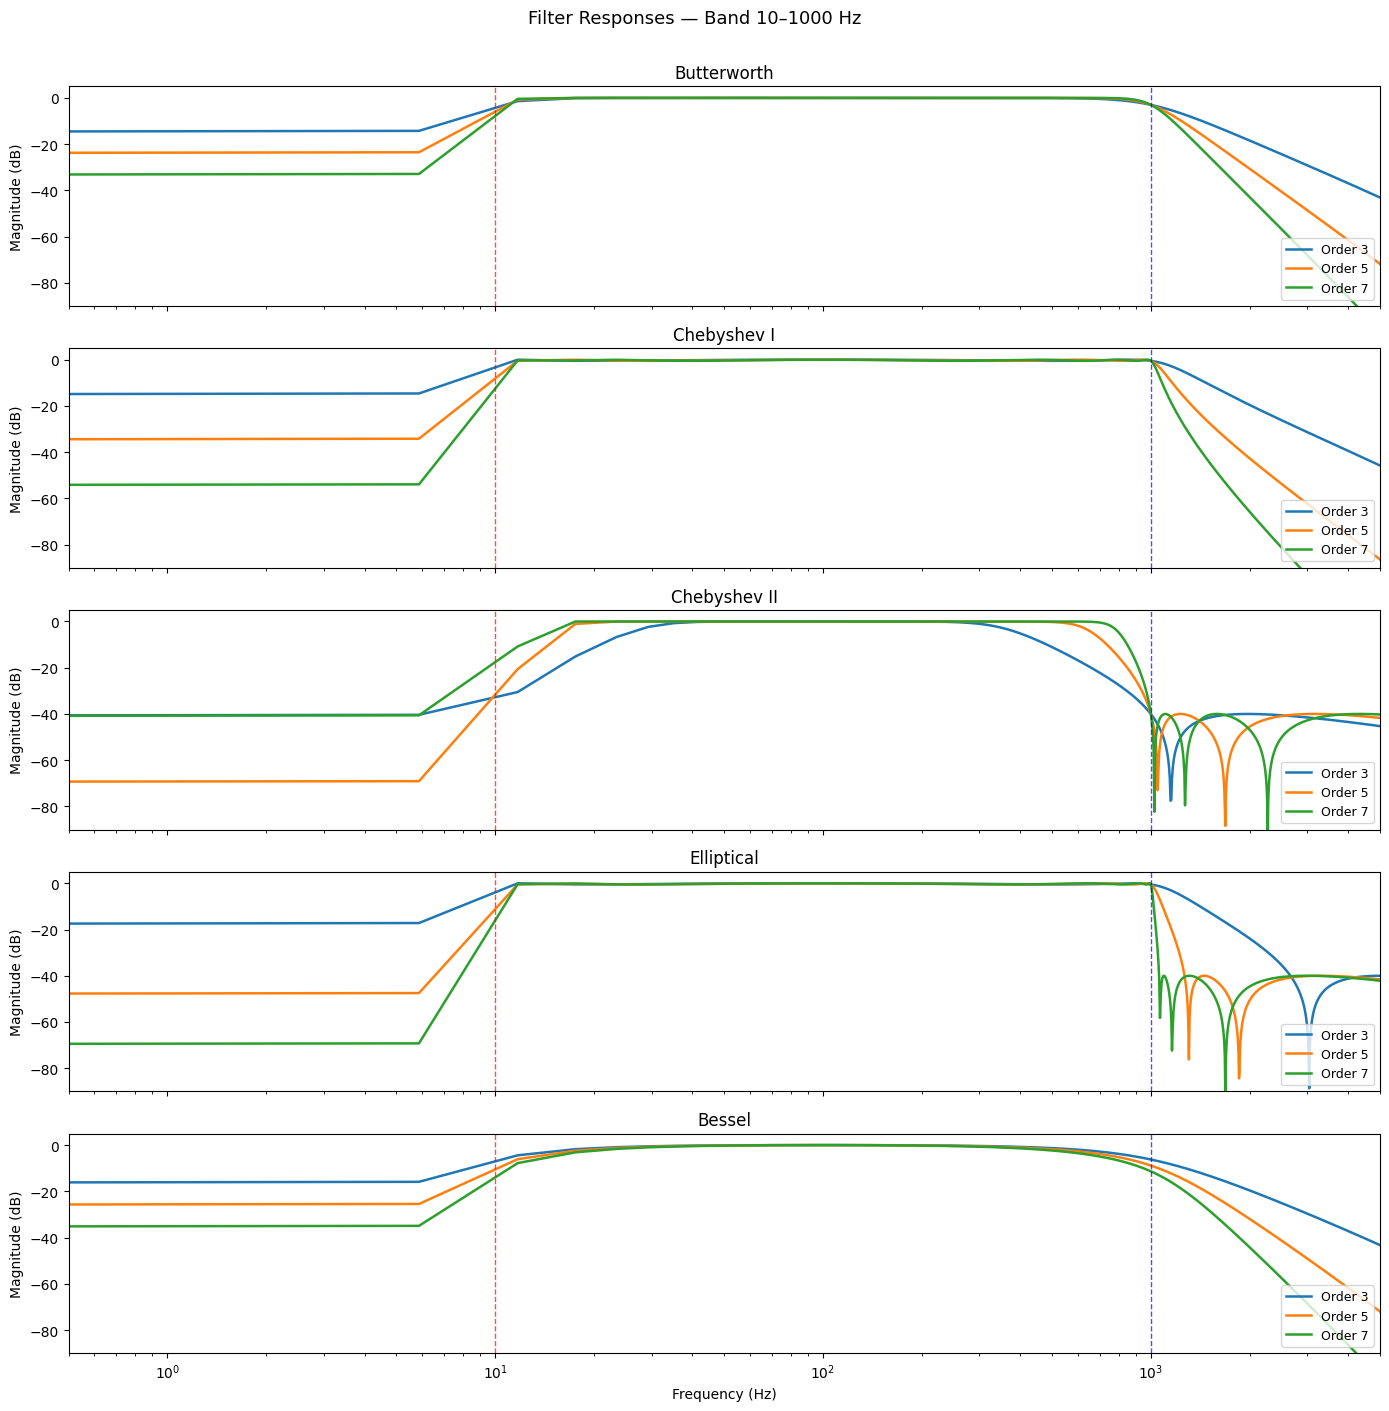


  PASS: 8/8  |  FAIL: 0/8
  Score: 100%


In [3]:
if not EXAMPLE_WAV: raise SystemExit
fs,signal,_ = load_wav(EXAMPLE_WAV)

filter_cache={}; errors=[]
for ftype,order,(lo,hi) in product(FILTER_TYPES,FILTER_ORDERS,zip(LOWER_LIMITS,UPPER_LIMITS)):
    key=(ftype,order,lo,hi)
    try:    filter_cache[key]=design_filter(ftype,order,lo,hi,fs)
    except Exception as e: errors.append(f"{ftype} N={order} {lo}–{hi}Hz: {e}"); filter_cache[key]=None

n_ok=sum(v is not None for v in filter_cache.values())
n_total=N_BANDS*len(FILTER_TYPES)*len(FILTER_ORDERS)

check("All filters designed without error",    len(errors)==0,   f"{n_ok}/{n_total} OK")
check("SOS arrays have 6 columns",
      all(v.shape[1]==6 for v in filter_cache.values() if v is not None))

# Passband gain check for demo band (10–1000 Hz)
lo_d,hi_d=10,1000; f_mid=(lo_d+hi_d)/2
for ftype in FILTER_TYPES:
    sos=filter_cache.get((ftype,5,lo_d,hi_d))
    if sos is None: continue
    w,h=sosfreqz(sos,worN=8192,fs=fs)
    gain=20*np.log10(np.abs(h[np.argmin(np.abs(w-f_mid))])+1e-12)
    check(f"{ftype}: passband gain at {f_mid:.0f} Hz > -6 dB", gain>-6.0, f"{gain:.1f} dB")

# Elliptical sharper than Bessel in stopband
sos_e=filter_cache.get(('Elliptical',5,lo_d,hi_d)); sos_b=filter_cache.get(('Bessel',5,lo_d,hi_d))
if sos_e is not None and sos_b is not None:
    w,h_e=sosfreqz(sos_e,worN=8192,fs=fs); _,h_b=sosfreqz(sos_b,worN=8192,fs=fs)
    si=np.argmin(np.abs(w-hi_d*1.5))  # near the transition edge, where elliptical's steeper rolloff actually beats bessel (elliptical's equiripple floor is overtaken by bessel's monotonic decay further into the stopband)
    check("Elliptical sharper stopband than Bessel",
          np.abs(h_e[si])<np.abs(h_b[si]), "sharper rolloff confirmed")

if errors: [print(f"  FAIL detail: {e}") for e in errors[:5]]

# Plot
fig,axes=plt.subplots(len(FILTER_TYPES),1,figsize=(14,14),sharex=True)
for ax,ftype in zip(axes,FILTER_TYPES):
    for order in FILTER_ORDERS:
        sos=filter_cache.get((ftype,order,lo_d,hi_d))
        if sos is None: continue
        w,h=sosfreqz(sos,worN=4096,fs=fs)
        ax.plot(w,20*np.log10(np.abs(h)+1e-12),label=f'Order {order}',lw=1.8)
    ax.axvline(lo_d,color='red',ls='--',lw=1,alpha=0.7)
    ax.axvline(hi_d,color='blue',ls='--',lw=1,alpha=0.7)
    ax.set_xlim(lo_d*0.05,hi_d*5); ax.set_ylim(-90,5)
    ax.set_ylabel('Magnitude (dB)'); ax.set_title(ftype); ax.legend(loc='lower right',fontsize=9); ax.set_xscale('log')
axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(f'Filter Responses — Band {lo_d}–{hi_d} Hz',fontsize=13,y=1.005)
plt.tight_layout(); plt.show(); plt.close('all')
summary()
